**Importa Bibliotecas principais**

In [1]:
# Ambiente novo: instala pacotes de gráficos (ignore se já instalados)
%pip install matplotlib seaborn -q

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path
from IPython.display import display

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

**Import do dataset**

In [3]:
# Carregamento do dataset


dataset_path = "../data/WA_Fn-UseC_-Telco-Customer-Churn.csv"



df = pd.read_csv(dataset_path)

print(f"Dataset carregado de: {dataset_path}")
print(f"Shape dos dados: {df.shape}")
print("\nPrimeiras linhas do dataset:")
display(df.head(10))

Dataset carregado de: ../data/WA_Fn-UseC_-Telco-Customer-Churn.csv
Shape dos dados: (7043, 21)

Primeiras linhas do dataset:


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.8500,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.9500,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.8500,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.3000,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.7000,151.65,Yes
5,9305-CDSKC,Female,0,No,No,8,Yes,Yes,Fiber optic,No,No,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.6500,820.5,Yes
6,1452-KIOVK,Male,0,No,Yes,22,Yes,Yes,Fiber optic,No,Yes,No,No,Yes,No,Month-to-month,Yes,Credit card (automatic),89.1000,1949.4,No
7,6713-OKOMC,Female,0,No,No,10,No,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,No,Mailed check,29.7500,301.9,No
8,7892-POOKP,Female,0,Yes,No,28,Yes,Yes,Fiber optic,No,No,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.8000,3046.05,Yes
9,6388-TABGU,Male,0,No,Yes,62,Yes,No,DSL,Yes,Yes,No,No,No,No,One year,No,Bank transfer (automatic),56.1500,3487.95,No


In [4]:
# Informações gerais sobre o dataset
print("=== INFORMAÇÕES GERAIS DO DATASET ===\n")
print(df.info())
print("\n=== ESTATÍSTICAS DESCRITIVAS ===\n")
df.describe()

=== INFORMAÇÕES GERAIS DO DATASET ===

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  Pap

,SeniorCitizen,tenure,MonthlyCharges
count,"7,043.0000","7,043.0000","7,043.0000"
mean,0.1621,32.3711,64.7617
std,0.3686,24.5595,30.0900
min,0.0000,0.0000,18.2500
25%,0.0000,9.0000,35.5000
50%,0.0000,29.0000,70.3500
75%,0.0000,55.0000,89.8500
max,1.0000,72.0000,118.7500


**Tratativa de coluna Object para float**

In [5]:
#Ajustes de padronizão de TotalCharges de objet to float
df[df["TotalCharges"].str.strip() == ""]
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors='coerce')
print("=== INFORMAÇÕES GERAIS DO DATASET ===\n")
print(df.info())
print("\n=== ESTATÍSTICAS DESCRITIVAS ===\n")
df.describe()

=== INFORMAÇÕES GERAIS DO DATASET ===

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  Pap

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,"7,043.0000","7,043.0000","7,043.0000","7,032.0000"
mean,0.1621,32.3711,64.7617,"2,283.3004"
std,0.3686,24.5595,30.0900,"2,266.7714"
min,0.0000,0.0000,18.2500,18.8000
25%,0.0000,9.0000,35.5000,401.4500
50%,0.0000,29.0000,70.3500,"1,397.4750"
75%,0.0000,55.0000,89.8500,"3,794.7375"
max,1.0000,72.0000,118.7500,"8,684.8000"


**Missing Values**

Verificando valores nulos no dataset:
customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64
=== ANÁLISE DE MISSING VALUES ===



,Coluna,Missing_Count,Missing_Percentage
TotalCharges,TotalCharges,11,0.1600


                    Coluna  Missing_Count  Missing_Percentage
TotalCharges  TotalCharges             11              0.1600


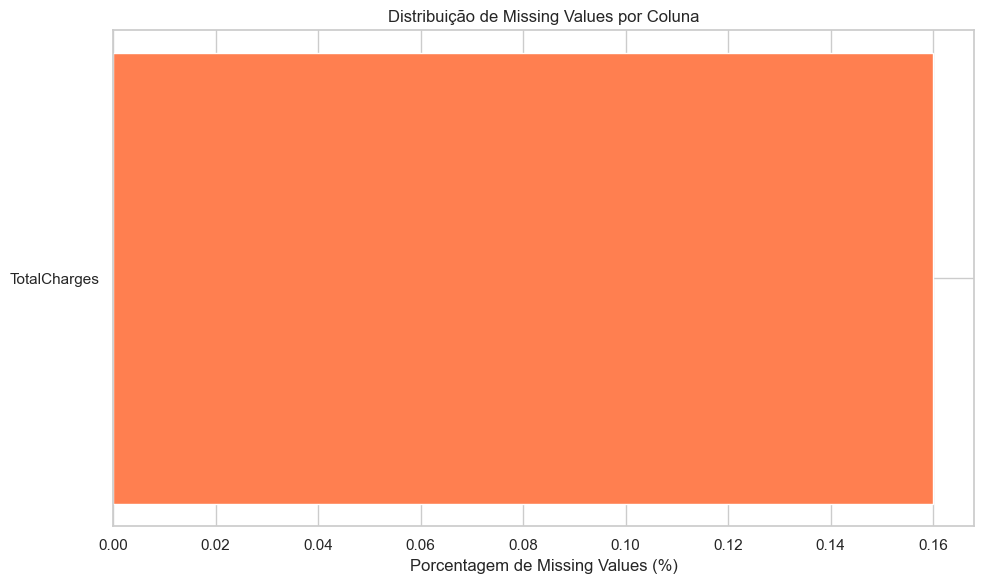

In [6]:
print('Verificando valores nulos no dataset:')
print(df.isnull().sum())

# Análise de valores ausentes
print("=== ANÁLISE DE MISSING VALUES ===\n")
missing_values = pd.DataFrame({
    'Coluna': df.columns,
    'Missing_Count': df.isnull().sum(),
    'Missing_Percentage':  (df.isnull().sum()  /  len(df)  * 100).round(2)})
missing_values = missing_values[missing_values['Missing_Count'] > 0].sort_values(by='Missing_Percentage', ascending=False)
display(missing_values)

if len(missing_values) > 0:
  print(missing_values)
  # Visualizar missing values
  plt.figure(figsize=(10, 6))
  plt.barh(missing_values['Coluna'],
missing_values['Missing_Percentage'], color='coral')
  plt.xlabel('Porcentagem de Missing Values (%)')
  plt.title('Distribuição de Missing Values por Coluna')
  plt.tight_layout()
  plt.show()
else:
  print("Nenhum missing valuedetectado!")

**Qualidade dos dados**

In [7]:
print("=== DUPLICATAS ===")
print(f"Linhas totalmente duplicadas: {df.duplicated().sum()}")

print("\n=== DUPLICATAS DE customerID ===")
if "customerID" in df.columns:
    print(f"customerID duplicados: {df['customerID'].duplicated().sum()}")

print("\n=== STRINGS VAZIAS POR COLUNA OBJECT ===")
object_cols = df.select_dtypes(include="object").columns.tolist()

empty_string_counts = {}
for col in object_cols:
    empty_string_counts[col] = (df[col].astype(str).str.strip() == "").sum()

empty_string_counts = {k: v for k, v in empty_string_counts.items() if v > 0}
print(empty_string_counts if empty_string_counts else "Nenhuma string vazia encontrada além das já tratadas.")

=== DUPLICATAS ===
Linhas totalmente duplicadas: 0

=== DUPLICATAS DE customerID ===
customerID duplicados: 0

=== STRINGS VAZIAS POR COLUNA OBJECT ===
Nenhuma string vazia encontrada além das já tratadas.


**Tratamento de missing values por mediana**

In [8]:
# Trata NaN populando pela mediana
mediana = df["TotalCharges"].median()
df["TotalCharges"] = df["TotalCharges"].fillna(mediana)

#revalida missing values pós tratativa
print('Verificando valores nulos no dataset:')
print(df.isnull().sum())

Verificando valores nulos no dataset:
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


**Distribuição da variavél target**

**Desbalanceamento da target e baseline ingênuo**

In [10]:
target_dist = df["target"].value_counts(normalize=True).sort_index()

print("=== DISTRIBUIÇÃO DA TARGET ===")
print(target_dist.rename(index={0: "Não churn", 1: "Churn"}))

majority_class = df["target"].mode()[0]
majority_share = df["target"].value_counts(normalize=True).max()

print("\n=== BASELINE INGÊNUO ===")
print(f"Classe majoritária: {majority_class}")
print(f"Acurácia de um classificador ingênuo (sempre prever a classe majoritária): {majority_share:.4f}")

=== DISTRIBUIÇÃO DA TARGET ===
target
Não churn   0.7346
Churn       0.2654
Name: proportion, dtype: float64

=== BASELINE INGÊNUO ===
Classe majoritária: 0
Acurácia de um classificador ingênuo (sempre prever a classe majoritária): 0.7346


**Análise de colunas numéricas**

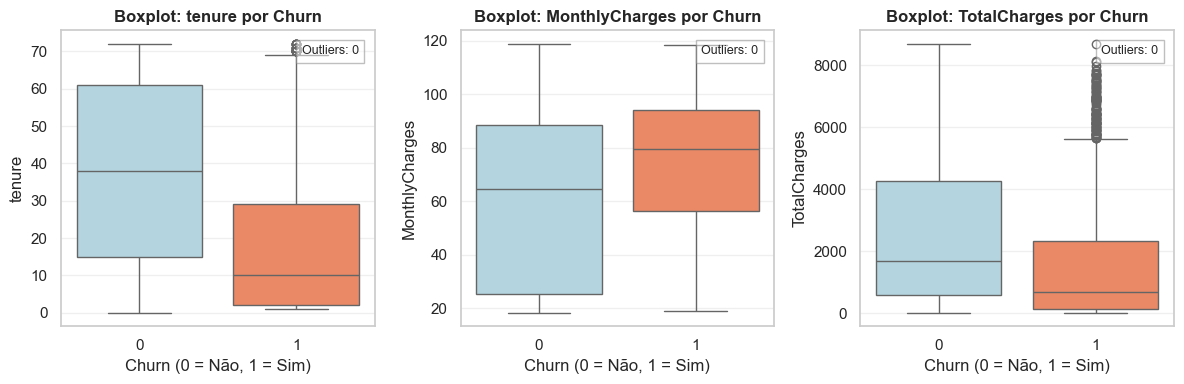

In [11]:
import scipy.stats as stats

# Colunas numéricas (excluindo id e target)
numeric_cols = df.select_dtypes(include=[np.number]).columns
numeric_cols = numeric_cols.drop(['target', 'SeniorCitizen'])

n = len(numeric_cols)
ncols = 3
nrows = int(np.ceil(n / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(12, 4 * nrows))
axes = axes.ravel()

for idx, col in enumerate(numeric_cols):
    sns.boxplot(
        x=df['target'].astype(str),
        y=col,
        data=df,
        ax=axes[idx],
        hue=df['target'].astype(str),
        palette={'0': 'lightblue', '1': 'coral'},
        legend=False
    )

    axes[idx].set_title(f'Boxplot: {col} por Churn', fontweight='bold')
    axes[idx].set_xlabel('Churn (0 = Não, 1 = Sim)')
    axes[idx].set_ylabel(col)
    axes[idx].grid(axis='y', alpha=0.3)

    # Cálculo de outliers via Z-score
    col_zscore = np.abs(stats.zscore(df[col].dropna()))
    outlier_count = (col_zscore > 3).sum()

    axes[idx].text(
        0.95, 0.95,
        f'Outliers: {outlier_count}',
        transform=axes[idx].transAxes,
        fontsize=9,
        verticalalignment='top',
        horizontalalignment='right',
        bbox=dict(facecolor='white', alpha=0.5, edgecolor='gray')
    )

# Remover subplots vazios
for ax in axes[n:]:
    fig.delaxes(ax)

plt.tight_layout()
plt.show()

**Histograma com distribuições sobrepostas**

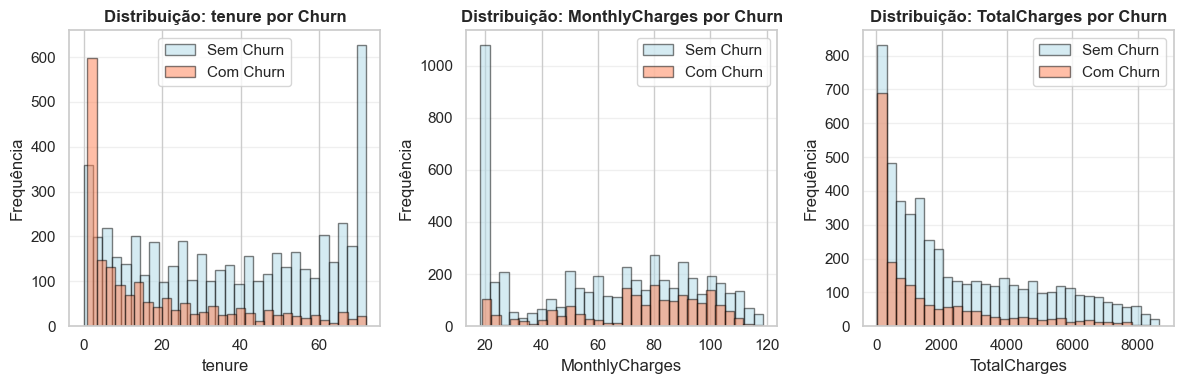

In [12]:
numeric_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

n = len(numeric_cols)
ncols = 3
nrows = int(np.ceil(n / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(12, 4 * nrows))
axes = axes.ravel()

for idx, col in enumerate(numeric_cols):

    # 1. Filtra os clientes que NÃO churnaram e pega só a coluna atual
    grupo_0 = df[df['target'] == 0][col]

    # 2. Filtra os clientes que churnaram e pega só a coluna atual
    grupo_1 = df[df['target'] == 1][col]

    # 3. Plota o grupo 0 no eixo atual
    axes[idx].hist(grupo_0, bins=30, alpha=0.5, color='lightblue', label='Sem Churn', edgecolor='black')

    # 4. Plota o grupo 1 no mesmo eixo
    axes[idx].hist(grupo_1, bins=30, alpha=0.5, color='coral', label='Com Churn', edgecolor='black')

    axes[idx].set_title(f'Distribuição: {col} por Churn', fontweight='bold')
    axes[idx].set_xlabel(col)
    axes[idx].set_ylabel('Frequência')
    axes[idx].legend()
    axes[idx].grid(axis='y', alpha=0.3)

for ax in axes[n:]:
    fig.delaxes(ax)

plt.tight_layout()
plt.show()

**Análise de Colunas categóricas**

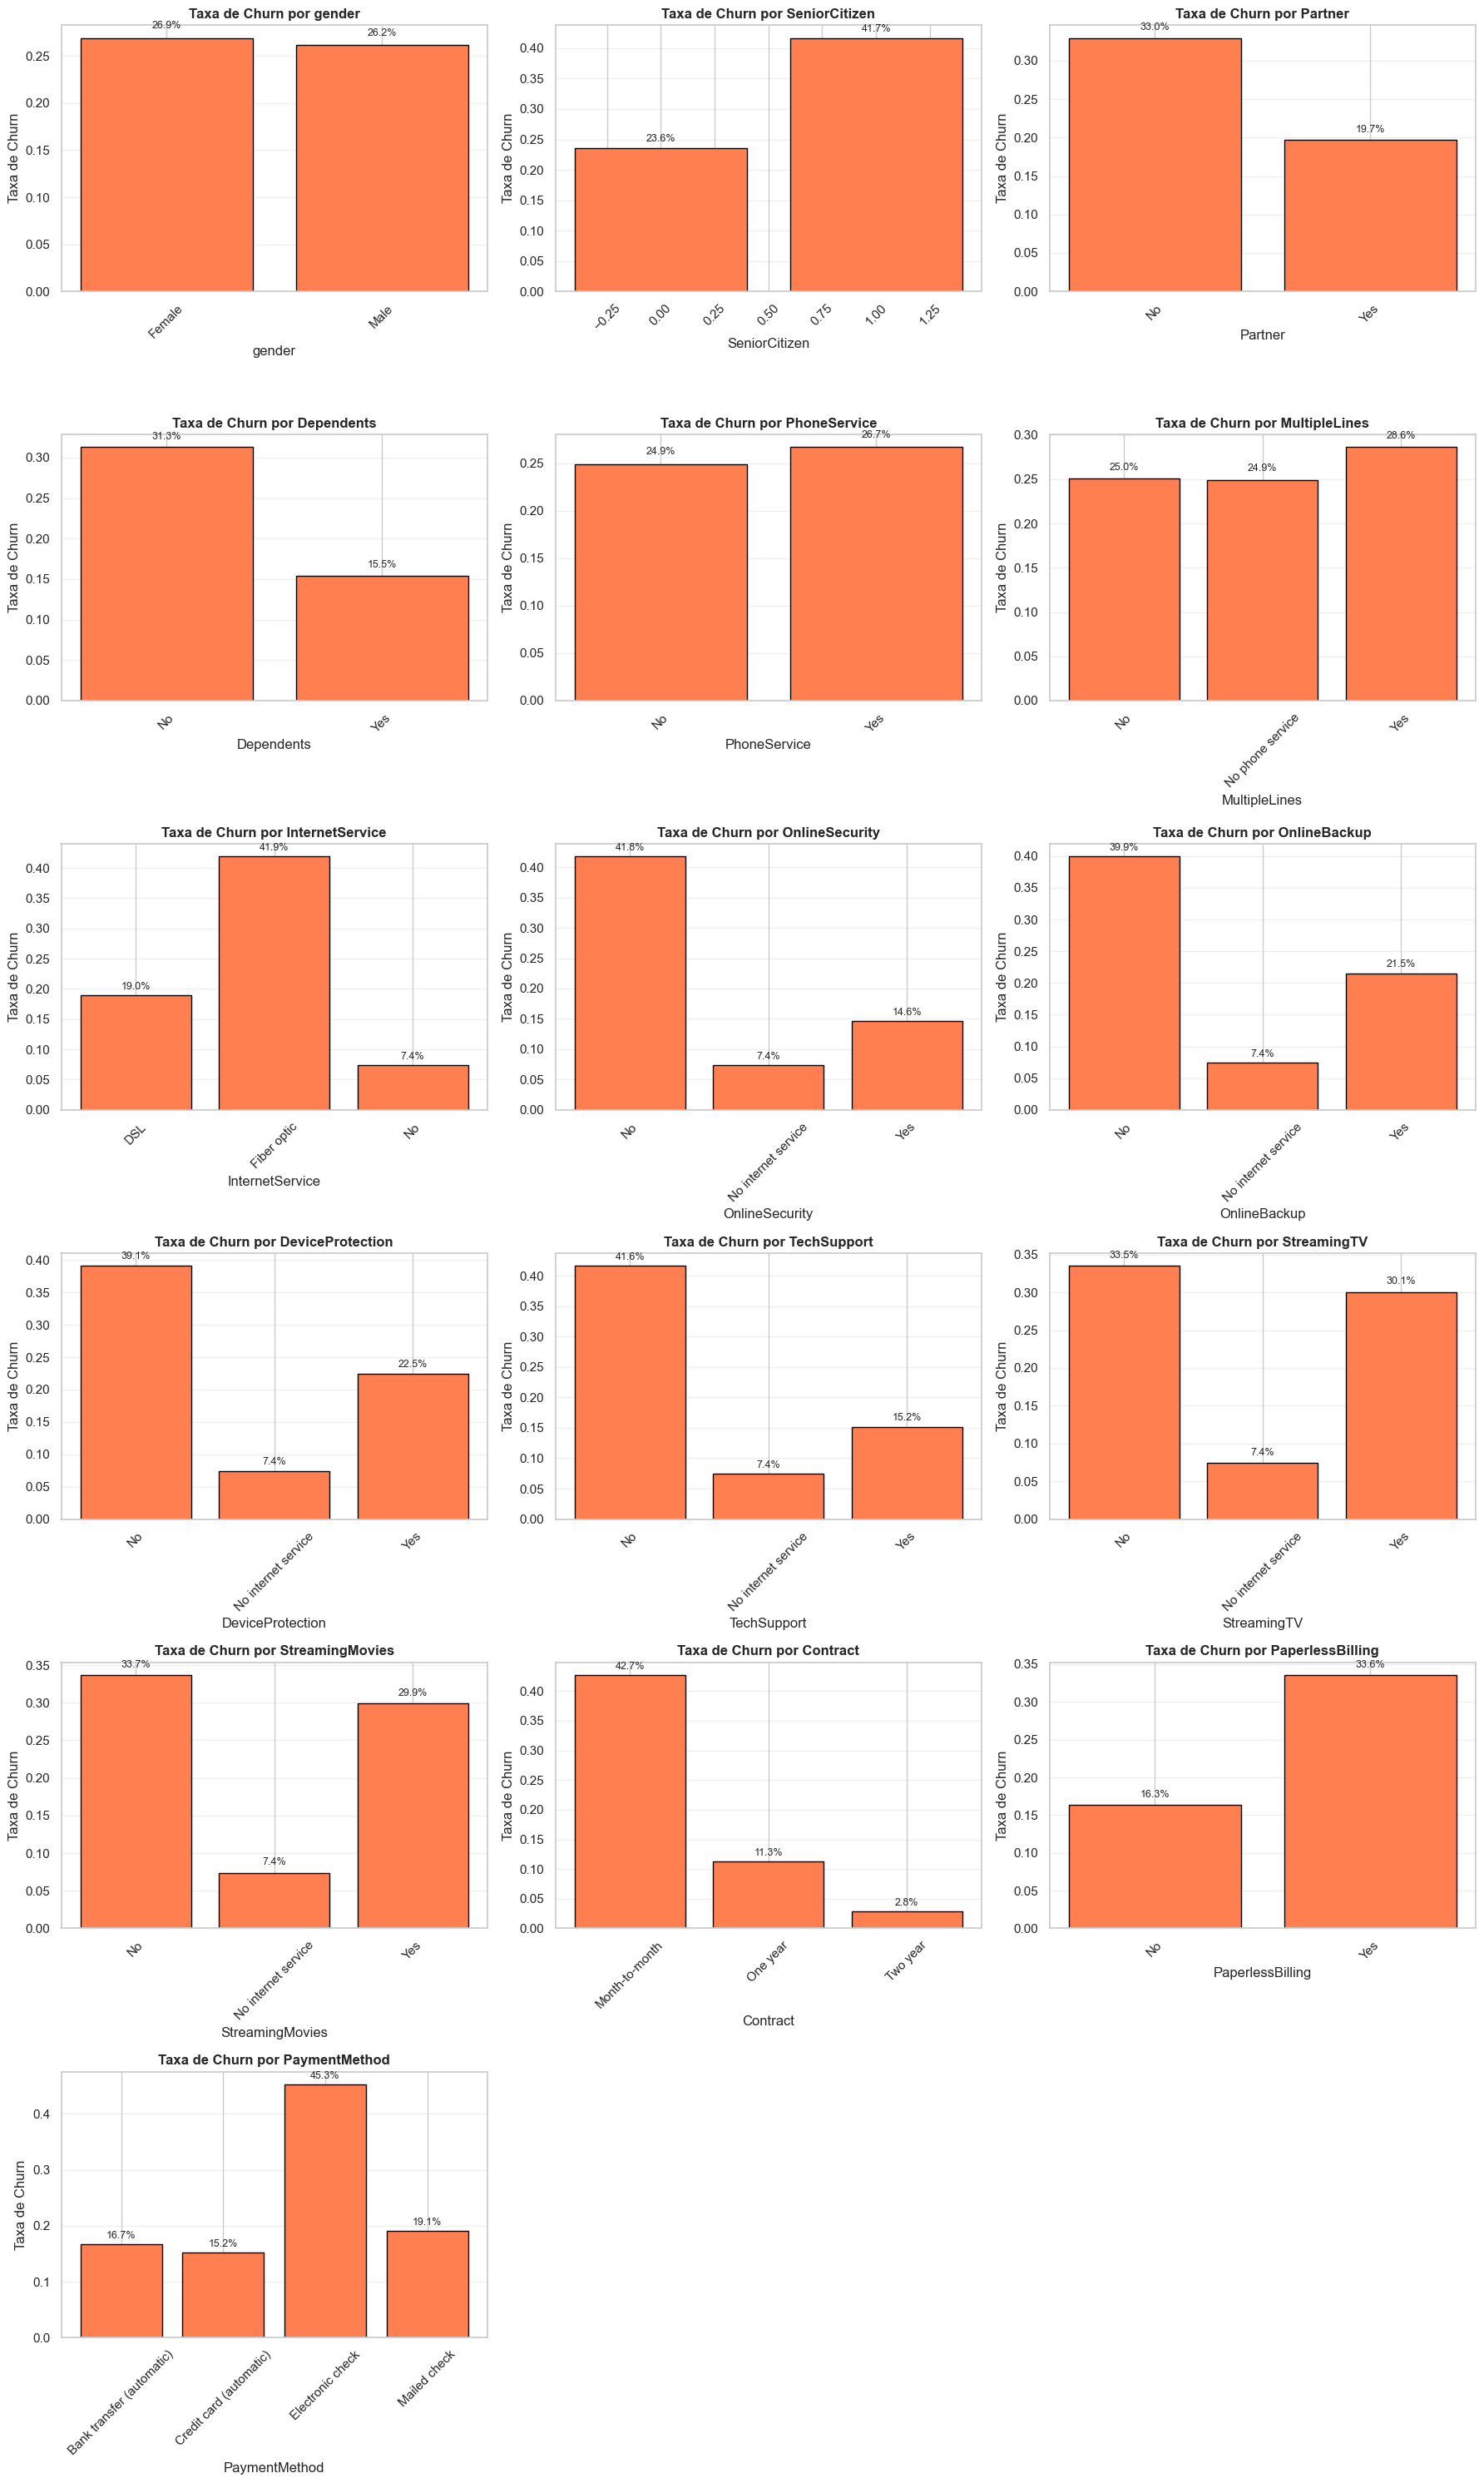

In [13]:
categorical_cols = [
    'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService',
    'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
    'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
    'Contract', 'PaperlessBilling', 'PaymentMethod'
]

# 1. Define o tamanho da grade de gráficos
n = len(categorical_cols)
ncols = 3
nrows = int(np.ceil(n / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(18, 5 * nrows))
axes = axes.ravel()

# 2. Loop por cada coluna categórica
for idx, col in enumerate(categorical_cols):

    # 43. Calcula a taxa de churn por categoria
    churn_rate = df.groupby(col)['target'].mean().reset_index()
    churn_rate.columns = [col, 'churn_rate']

    # 4. Plota o barplot
    axes[idx].bar(
        churn_rate[col],
        churn_rate['churn_rate'],
        color='coral',
        edgecolor='black'
    )

    # 5. Títulos e labels
    axes[idx].set_title(f'Taxa de Churn por {col}', fontweight='bold')
    axes[idx].set_xlabel(col)
    axes[idx].set_ylabel('Taxa de Churn')
    axes[idx].tick_params(axis='x', rotation=45)
    axes[idx].grid(axis='y', alpha=0.3)

    # 6. Adiciona o valor percentual em cima de cada barra
    for bar, rate in zip(axes[idx].patches, churn_rate['churn_rate']):
        axes[idx].text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.01,
            f'{rate:.1%}',
            ha='center',
            fontsize=9
        )

# 7. Remove subplots vazios
for ax in axes[n:]:
    fig.delaxes(ax)

plt.tight_layout()
plt.show()

OnlineSecurity e TechSupport — clientes sem esses serviços churnaram bastante

InternetService — clientes com fibra churnaram mais que DSL

PaymentMethod — Electronic check tem taxa bem acima das outras

**Correlações**

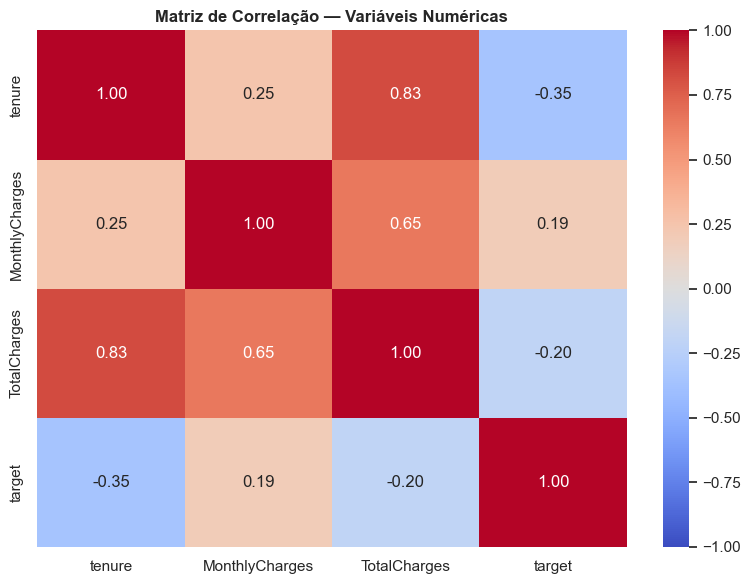

In [14]:
numeric_for_corr = df[['tenure', 'MonthlyCharges', 'TotalCharges', 'target']]

correlation_matrix = numeric_for_corr.corr()

fig, ax = plt.subplots(figsize=(8, 6))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    vmin=-1,
    vmax=1,
    ax=ax
)

ax.set_title('Matriz de Correlação — Variáveis Numéricas', fontweight='bold')
plt.tight_layout()
plt.show()

**Inventário de variáveis para modelagem**

In [20]:
target_col = "target"

numeric_features = [col for col in df.select_dtypes(include=[np.number]).columns if col != target_col]
categorical_features = [col for col in df.columns if col not in numeric_features + [target_col]]

if "customerID" in categorical_features:
    categorical_features.remove("customerID")

print("=== INVENTÁRIO DE FEATURES ===")
print(f"Target: {target_col}")
print(f"Total de features numéricas: {len(numeric_features)}")
print(numeric_features)
print(f"\nTotal de features categóricas: {len(categorical_features)}")
print(categorical_features)


=== INVENTÁRIO DE FEATURES ===
Target: target
Total de features numéricas: 4
['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']

Total de features categóricas: 15
['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


**Associação das variáveis com a target**

In [16]:
print("=== ASSOCIAÇÃO DAS VARIÁVEIS NUMÉRICAS COM A TARGET ===")
numeric_assoc = (
    df[numeric_features + [target_col]]
    .corr(numeric_only=True)[target_col]
    .drop(target_col)
    .sort_values(key=np.abs, ascending=False)
)
display(numeric_assoc.to_frame(name="correlacao_com_target"))

print("\n=== ASSOCIAÇÃO DAS VARIÁVEIS CATEGÓRICAS COM A TARGET ===")
cat_signal = []

for col in categorical_features:
    churn_rates = df.groupby(col)[target_col].mean()
    signal = churn_rates.max() - churn_rates.min()
    cat_signal.append({
        "feature": col,
        "min_churn_rate": churn_rates.min(),
        "max_churn_rate": churn_rates.max(),
        "spread_churn_rate": signal,
        "n_categorias": df[col].nunique()
    })

cat_signal_df = pd.DataFrame(cat_signal).sort_values("spread_churn_rate", ascending=False)
display(cat_signal_df)

=== ASSOCIAÇÃO DAS VARIÁVEIS NUMÉRICAS COM A TARGET ===


,correlacao_com_target
tenure,-0.3522
TotalCharges,-0.1990
MonthlyCharges,0.1934
SeniorCitizen,0.1509



=== ASSOCIAÇÃO DAS VARIÁVEIS CATEGÓRICAS COM A TARGET ===


,feature,min_churn_rate,max_churn_rate,spread_churn_rate,n_categorias
12,Contract,0.0283,0.4271,0.3988,3
5,InternetService,0.0740,0.4189,0.3449,3
6,OnlineSecurity,0.0740,0.4177,0.3436,3
9,TechSupport,0.0740,0.4164,0.3423,3
7,OnlineBackup,0.0740,0.3993,0.3252,3
8,DeviceProtection,0.0740,0.3913,0.3172,3
14,PaymentMethod,0.1524,0.4529,0.3004,4
11,StreamingMovies,0.0740,0.3368,0.2628,3
10,StreamingTV,0.0740,0.3352,0.2612,3
13,PaperlessBilling,0.1633,0.3357,0.1724,2


## Data Readiness Assessment

| Critério | Status | Observação |
|---|---|---|
| Volume | ✅ OK | 7.043 registros (>5.000 exigido) |
| Features | ✅ OK | 19 features + 1 target (>10 exigido) |
| Missing values | ✅ Tratado | 11 NaN em TotalCharges → preenchidos com mediana, para não causar remoção |
| Tipos de dados | ✅ Tratado | TotalCharges convertido de object para float |
| Desbalanceamento | ⚠️ Atenção | ~26.5% churn vs 73.5% não-churn — Vamos utilizar validação estratificada |
| Multicolinearidade | ⚠️ Atenção | tenure × TotalCharges = 0.83  |
| Leakage | ✅ OK | Nenhuma feature contém informação futura |
| Data freshness | ℹ️ Info | Dataset estático/acadêmico — sem atualização temporal |



## Conclusões do EDA 

### Principais achados
- A base possui volume adequado para o desafio, com mais de 7 mil registros e número suficiente de variáveis.
- A variável `TotalCharges` exigiu tratamento por estar como `object` e conter valores vazios.
- O target apresenta desbalanceamento moderado, com churn em torno de 26,5%, o que reforça a necessidade de validação estratificada e uso de métricas além de acurácia.
- Variáveis como `tenure`, `Contract`, `InternetService`, `OnlineSecurity`, `TechSupport` e `PaymentMethod` mostraram relação importante com churn.
- Há correlação alta entre `tenure` e `TotalCharges`, o que merece atenção na modelagem.
- MonthlyCharges e TotalCharges → 0.65 — correlação moderada 
- Tenure e target → -0.35 — quanto mais tempo de contrato, menos churn 
- MonthlyCharges e target → 0.19 — quem paga mais churna levemente mais 
- TotalCharges e target → -0.20 — correlação fraca e redundante com tenure